# Phase 4: 合成データ・リカバリーテストを全7試合で実施 — Colab

**目的**: J03WPY 1試合で見つかった「二重メカニズム」仮説
(短い$\Delta t$の不安定性は測定誤差、長い$\Delta t$の不安定性はモデルの限界=真の時間依存性で説明できる、
`documents/phase4_synthetic_recovery_results.md`)が、他の試合でも再現するか確認する。

実行するロジックは `scripts/phase4_synthetic_recovery.py`(試合ごとにPINNを学習し、
Baseline1と同じ推定器を合成データ6条件[定数×ノイズ4段階、時間変化×ノイズ有無]に適用、
実データの$V_{max}(\Delta t)$曲線と比較)。

**実行前に**: メニューの `ランタイム > ランタイムのタイプを変更` で **GPU** を選択してください。

## 1. Google Drive をマウント(結果の永続化用)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

OUT_DIR = '/content/drive/MyDrive/pi-fsm/phase4_synthetic_recovery_multi'
import os
os.makedirs(OUT_DIR, exist_ok=True)
print('results will be saved to', OUT_DIR)

Mounted at /content/drive
results will be saved to /content/drive/MyDrive/pi-fsm/phase4_synthetic_recovery_multi


## 2. リポジトリを取得

In [2]:
%cd /content
if not os.path.exists('/content/pi-fsm'):
    !git clone https://github.com/ryu622/pi-fsm.git
%cd /content/pi-fsm
!git pull
!git log --oneline -5

/content
Cloning into 'pi-fsm'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 173 (delta 74), reused 137 (delta 42), pack-reused 0 (from 0)
Receiving objects: 100% (173/173), 4.47 MiB | 112.00 KiB/s, done.
Resolving deltas: 100% (74/74), done.
/content/pi-fsm
Already up to date.
d998122 (HEAD -> main, origin/main, origin/HEAD) Add Colab notebook for phase4 multi-match synthetic recovery run
b9e54b4 Generalize phase4_synthetic_recovery.py to run across all matches
b8c78c4 Phase 4: final 6-condition comparison suggests a two-regime explanation
b2d0bab Confirm PINN's F(t),k(t) shape is consistent across matches
a8b2e2f Phase 4 first pass: synthetic recovery test infrastructure


## 3. 依存関係のインストール

In [3]:
!pip install -q -e .

import torch
print('torch', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if not torch.cuda.is_available():
    print('WARNING: no GPU detected — go to ランタイム > ランタイムのタイプを変更 > GPU')

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. 全7試合で合成データ・リカバリーテストを実行

試合ごとにPINNを学習(1試合あたりローカルCPU/MPSで約7〜8分、GPUならもっと速いはず)+ 6条件の合成シミュレーション。
中断しても完了済みの試合(`{OUT_DIR}/synthetic_recovery_<match_id>.csv` が存在するもの)はスキップされるので再実行して問題ない。

In [4]:
!python scripts/phase4_synthetic_recovery.py --out-dir "{OUT_DIR}"


===== J03WPY =====
training PINN on real J03WPY data (t<=2.5s) for the time-varying ground truth...
trained in 334s, L_data=0.990
--- constant_no_noise ---
  dt=0.2: alpha=0.9525946580636798, vmax=12.421476083892612
  dt=0.48: alpha=0.9472145873764266, vmax=12.400887109822321
  dt=1.0: alpha=0.9445462083865073, vmax=12.396038910491137
  dt=2.0: alpha=0.9417743159168893, vmax=12.394355235445824
  dt=3.0: alpha=0.9391131392599623, vmax=12.393890612348988
  (1s)
--- constant_noise_sigma0.1 ---
  dt=0.2: alpha=0.954002613299012, vmax=13.751201313143842
  dt=0.48: alpha=0.9469649643193817, vmax=12.45086120928947
  dt=1.0: alpha=0.9443102489358196, vmax=12.401409415048123
  dt=2.0: alpha=0.9417676673820315, vmax=12.395246256336515
  dt=3.0: alpha=0.9390373130633389, vmax=12.394263570546292
  (1s)
--- constant_noise_sigma0.3 ---
  dt=0.2: alpha=0.9568196313941585, vmax=23.65160776543766
  dt=0.48: alpha=0.9464657099315955, vmax=12.828583701246862
  dt=1.0: alpha=0.9438385120182519, vmax=12.4

## 5. 結果の確認

試合ごとの条件別 Vmax(delta_t):


condition         constant_no_noise  constant_noise_sigma0.1  \
match_id delta_t                                               
J03WMX   0.20                 12.69                    14.10   
         0.48                 12.66                    12.72   
         1.00                 12.66                    12.66   
         2.00                 12.66                    12.66   
         3.00                 12.66                    12.66   
J03WN1   0.20                 12.38                    13.76   
         0.48                 12.36                    12.41   
         1.00                 12.35                    12.36   
         2.00                 12.35                    12.35   
         3.00                 12.35                    12.35   
J03WOH   0.20                 11.17                    12.32   
         0.48                 11.16                    11.20   
         1.00                 11.15                    11.16   
         2.00                 11.15                    11.15   
         3.00                 11.15                    11.15   
J03WOY   0.20                 12.17                    13.39   
         0.48                 12.15                    12.19   
         1.00                 12.14                    12.15   
         2.00                 12.14                    12.14   
         3.00                 12.14                    12.14   
J03WPY   0.20                 12.42                    13.75   
         0.48                 12.40                    12.45   
         1.00                 12.40                    12.40   
         2.00                 12.39                    12.40   
         3.00                 12.39                    12.39   
J03WQQ   0.20                 11.50                    12.64   
         0.48                 11.48                    11.53   
         1.00                 11.48                    11.49   
         2.00                 11.48                    11.48   
         3.00                 11.48                    11.48   
J03WR9   0.20                 11.42                    12.64   
         0.48                 11.40                    11.45   
         1.00                 11.40                    11.40   
         2.00                 11.40                    11.40   
         3.00                 11.40                    11.40   

condition         constant_noise_sigma0.3  constant_noise_sigma0.5  \
match_id delta_t                                                     
J03WMX   0.20                       24.50                    37.76   
         0.48                       13.11                    13.96   
         1.00                       12.70                    12.75   
         2.00                       12.66                    12.67   
         3.00                       12.66                    12.66   
J03WN1   0.20                       23.89                    36.83   
         0.48                       12.80                    13.62   
         1.00                       12.39                    12.45   
         2.00                       12.36                    12.36   
         3.00                       12.35                    12.36   
J03WOH   0.20                       20.99                    32.21   
         0.48                       11.53                    12.24   
         1.00                       11.18                    11.23   
         2.00                       11.15                    11.16   
         3.00                       11.15                    11.15   
J03WOY   0.20                       22.68                    34.75   
         0.48                       12.55                    13.29   
         1.00                       12.18                    12.23   
         2.00                       12.15                    12.15   
         3.00                       12.14                    12.14   
J03WPY   0.20                       23.65                    36.37   
         0.48        

--- J03WPY ---


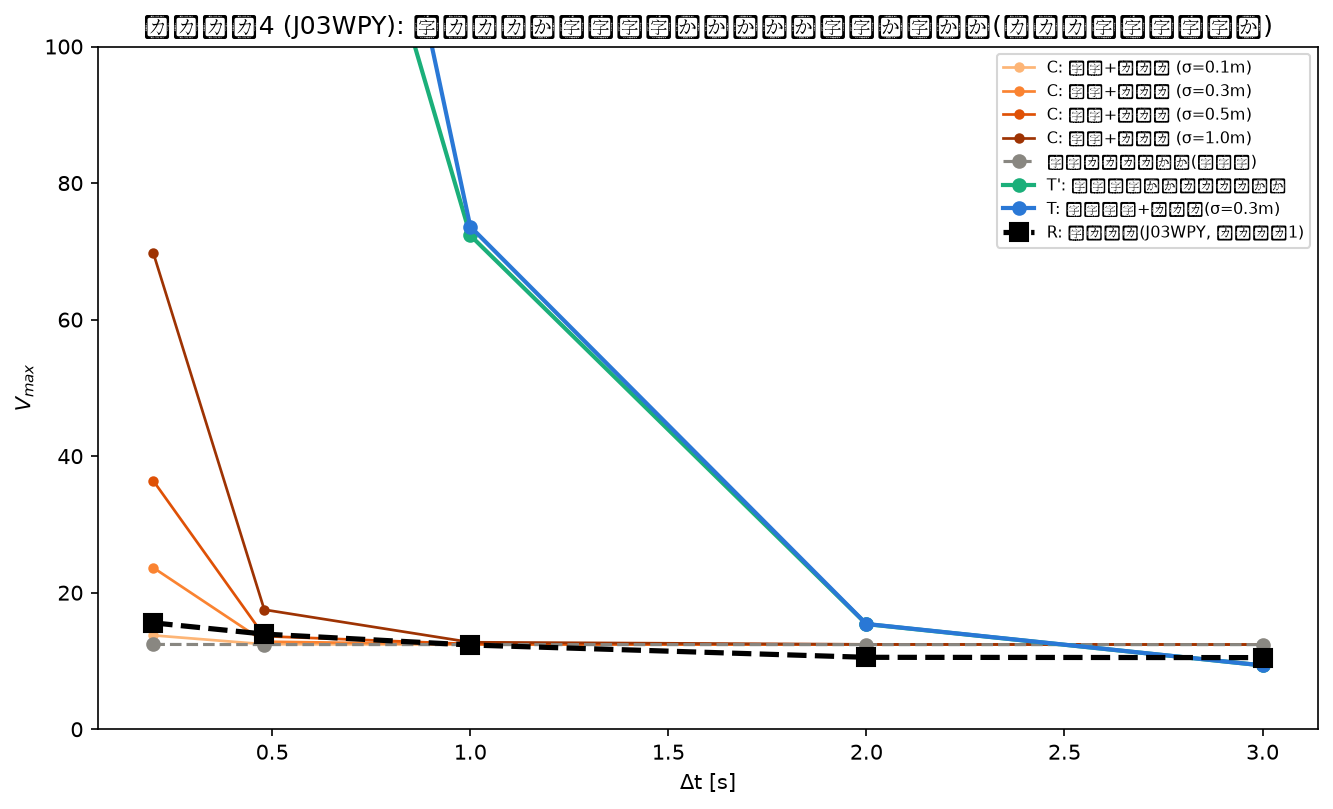

--- J03WMX ---


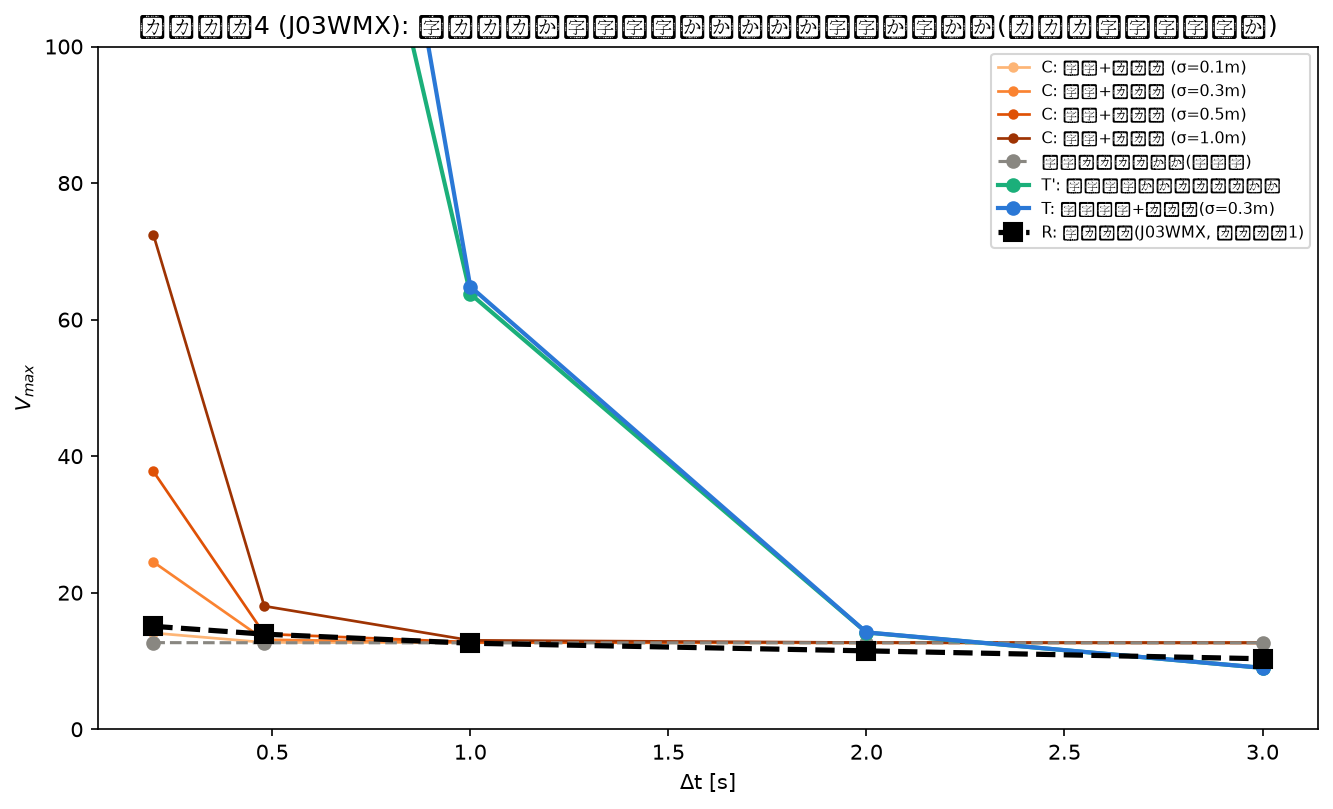

--- J03WN1 ---


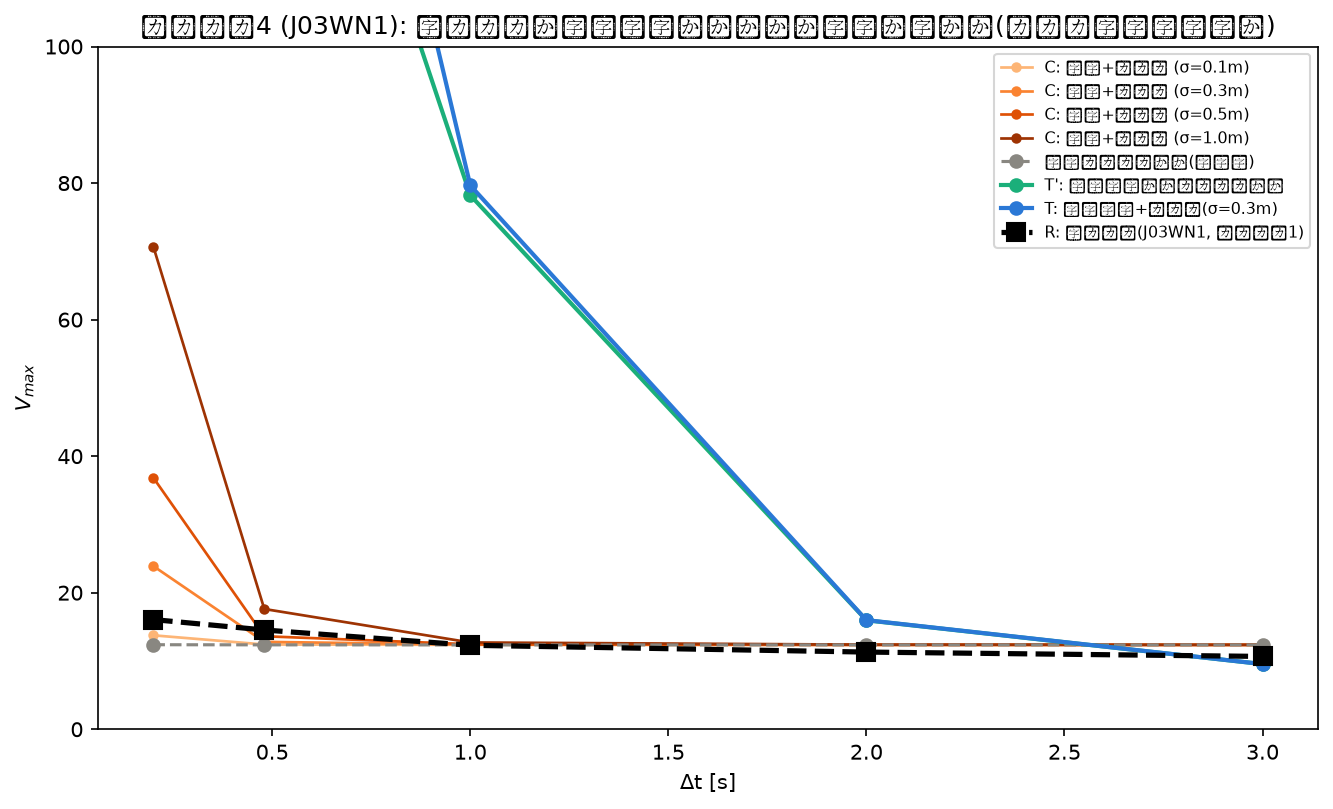

--- J03WOH ---


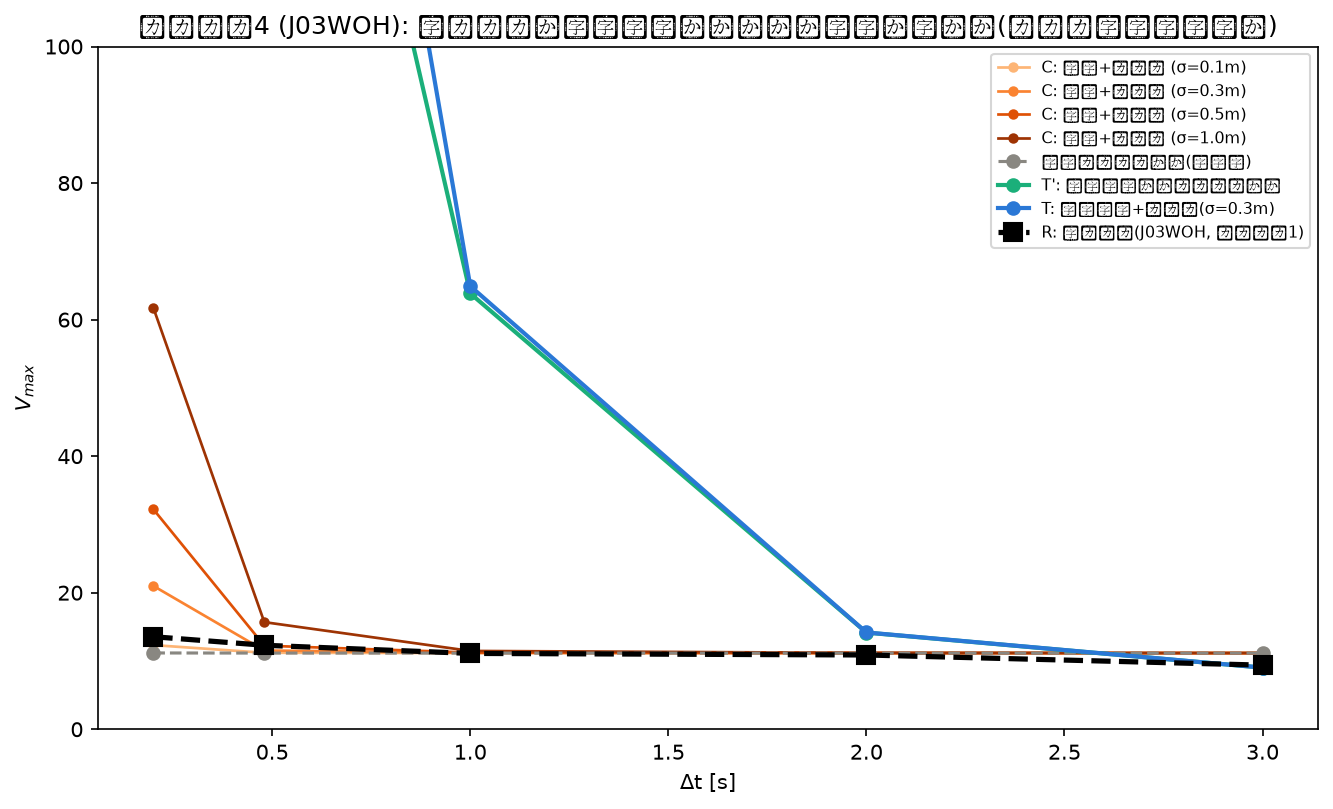

--- J03WOY ---


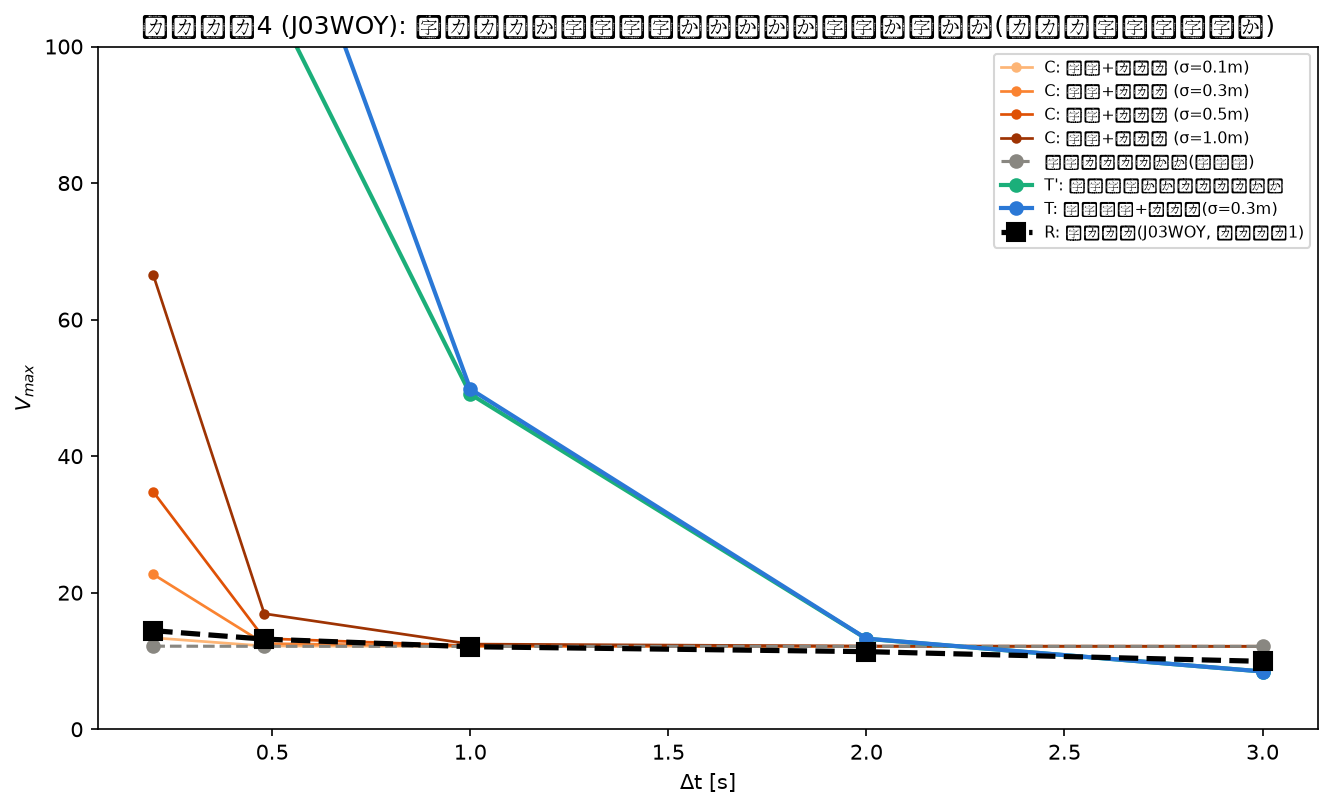

--- J03WQQ ---


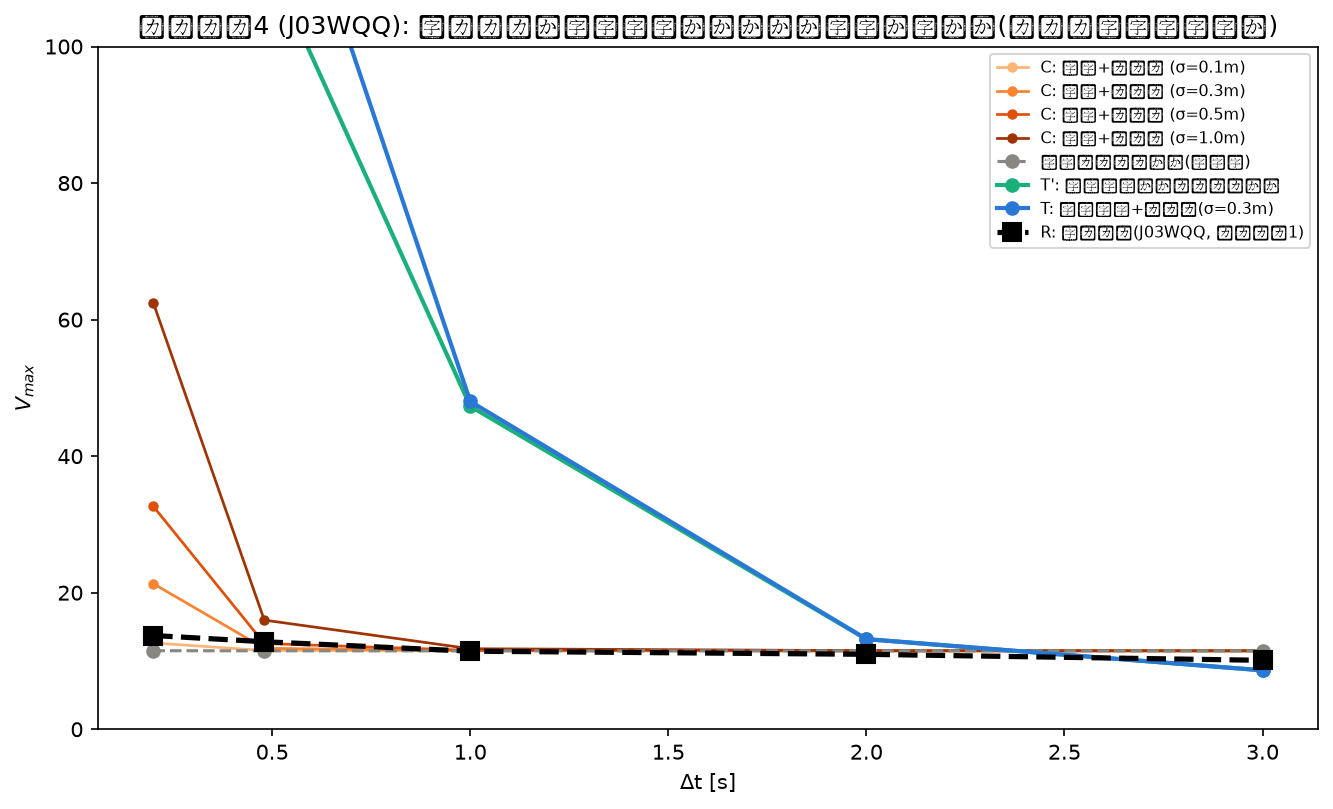

--- J03WR9 ---


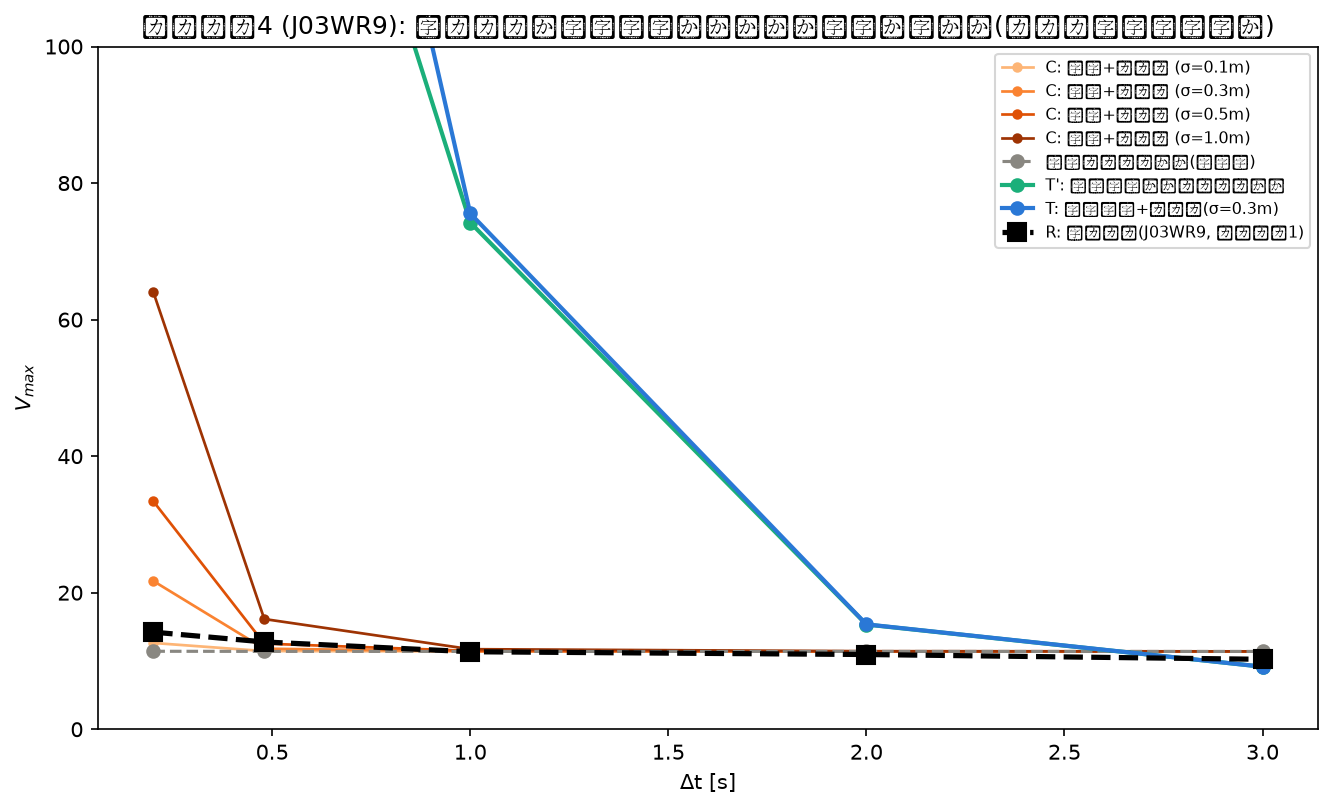

In [5]:
import pandas as pd
from IPython.display import Image, display

combined = pd.read_csv(f'{OUT_DIR}/synthetic_recovery_all_matches.csv')
print('試合ごとの条件別 Vmax(delta_t):')
display(combined.pivot_table(index=['match_id', 'delta_t'], columns='condition', values='vmax').round(2))

# 各試合について図を表示
for match_id in combined['match_id'].unique():
    print(f'--- {match_id} ---')
    display(Image(f'{OUT_DIR}/synthetic_recovery_{match_id}.png'))

## 次のステップ

- 各試合で「短い$\Delta t$は測定誤差(ノイズ条件のどれかに近い)、長い$\Delta t$は時間変化のみ・ノイズなし条件に近い」
  という同じパターンが見られれば、J03WPYの二重メカニズムの結論が一般的なものだと確認できる
- 結果はDriveの `{OUT_DIR}` に試合ごとのCSV/PNG + `synthetic_recovery_all_matches.csv` として永続化される
- 確認できたら `documents/phase4_synthetic_recovery_results.md` に7試合分の結果をまとめる